# 氣溫走勢與風險建模

研究 **WU 逐時預報曲線的形狀** 如何影響 **當天實際最高溫的偏離與不確定性**，為 Polymarket 每日最高溫市場提供風險評估。

核心問題：

- 預報下午 1–5pm 都 15°C 的「平台型」走勢，是不是比「尖峰型」更容易突破到 16°C？
- 哪些天氣 / 走勢特徵讓「實際最高溫」最難預測（= 下注風險最高）？

產出：

1. **殘差分析** — WU 預報峰值 vs 實際最高溫的系統性偏差
2. **平台期假設檢定** — 平台寬度 → 突破機率 / 殘差變異（統計）
3. **分位數回歸風險帶** — 預測當天最高溫的 P10 / P50 / P90，定義「風險分數」（ML）
4. **特徵重要性** — 什麼決定實際高溫、什麼決定風險
5. **Polymarket 區間命中** — 模型 vs 市場隱含機率，找錯價
6. **誠實驗證** — 模型有沒有打敗「直接相信預報」

> 資料來源：`forecast_hourly_snapshots`（逐時預報曲線）+ `weather_daily_summary`（官方最高溫）+ `market_options` / `market_snapshots`（區間定義與賠率）。
> 每一列 = 一個（城市 × 日期）。預報快照取「結算前約 `LEAD_HOURS_TARGET` 小時」那一張（≈ 目標日清晨，曲線仍涵蓋下午高峰）。


## ⚙️ 參數設定（只需改這裡）

In [16]:
# ── 城市選擇 ──────────────────────────────────────────────────────────────────
# "ALL" = 14 城市一起建模（樣本最多，推薦）；或填單一城市 location_key（例 "us/fl/miami/KMIA"）
CITY = "ALL"

# ── 預報快照選擇 ──────────────────────────────────────────────────────────────
LEAD_HOURS_TARGET  = 20        # 取「距結算約這麼多小時」的那張快照（20h ≈ 目標日清晨）
LEAD_HOURS_WINDOW  = (14, 30)  # 可接受的 hours_before_close 範圍
MIN_FORECAST_HOURS = 16        # 該快照至少要涵蓋幾個小時（確保抓到下午高峰）
SINCE_DATE         = "2026-03-01"  # 排除 collector 修正前的不可靠資料

# ── 假設檢定參數 ──────────────────────────────────────────────────────────────
PLATEAU_TOL_F = 1.0            # 「平台期」= 預報溫度在峰值往下 PLATEAU_TOL_F 度內的小時數
PEAK_WINDOW   = (11, 19)       # 認定「下午高峰」的本地小時範圍（找峰值只看這段，避免雜訊）

# ── 機器學習 ──────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_CV_SPLITS = 5                # 以「日期」分組的交叉驗證折數
QUANTILES   = [0.10, 0.50, 0.90]
PEAK_FEE    = 0.0125           # Polymarket 動態 taker 費率峰值（區間分析參考用）

## 🔧 核心程式（不需修改）

In [17]:
import os, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from psycopg2.extras import execute_values
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = ["Arial Unicode MS", "Heiti TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(RANDOM_SEED)
load_dotenv(Path("..") / ".env")

# ── 城市元資料 ────────────────────────────────────────────────────────────────
CITY_NAMES = {
    "us/ny/new-york-city/KLGA": "NYC", "us/il/chicago/KORD": "Chicago",
    "gb/london/EGLC": "London", "us/fl/miami/KMIA": "Miami",
    "us/ga/atlanta/KATL": "Atlanta", "us/tx/dallas/KDAL": "Dallas",
    "us/wa/seatac/KSEA": "Seattle", "ca/mississauga/CYYZ": "Toronto",
    "fr/paris/LFPG": "Paris", "tr/çubuk/LTAC": "Ankara",
    "kr/incheon/RKSI": "Incheon", "nz/wellington/NZWN": "Wellington",
    "br/guarulhos/SBGR": "SaoPaulo", "ar/ezeiza/SAEZ": "BuenosAires",
}
CITY_LAT = {
    "us/ny/new-york-city/KLGA": 40.8, "us/il/chicago/KORD": 42.0, "gb/london/EGLC": 51.5,
    "us/fl/miami/KMIA": 25.8, "us/ga/atlanta/KATL": 33.7, "us/tx/dallas/KDAL": 32.8,
    "us/wa/seatac/KSEA": 47.4, "ca/mississauga/CYYZ": 43.7, "fr/paris/LFPG": 49.0,
    "tr/çubuk/LTAC": 40.0, "kr/incheon/RKSI": 37.5, "nz/wellington/NZWN": -41.3,
    "br/guarulhos/SBGR": -23.4, "ar/ezeiza/SAEZ": -34.8,
}
def climate_zone(lat):
    a = abs(lat)
    if a < 23.5: return "tropical"
    if a < 35:   return "subtropical"
    if a < 50:   return "temperate"
    return "cool"

def get_conn():
    return psycopg2.connect(os.environ["DATABASE_URL"], sslmode="require",
                            keepalives=1, keepalives_idle=30,
                            keepalives_interval=10, keepalives_count=5)

# ── 1. 取代表性預報快照（每城市每天一張）+ 當天官方最高溫 ─────────────────────
conn = get_conn()
lo_lead, hi_lead = LEAD_HOURS_WINDOW
city_filter = "" if CITY == "ALL" else "AND fs.location_key = %(city)s"
base = pd.read_sql(f"""
    WITH picked AS (
      SELECT DISTINCT ON (fs.location_key, fs.target_date)
             fs.location_key, fs.target_date, fs.snapshot_time,
             fs.hours_before_close, fs.n_forecast_hours
      FROM forecast_snapshots fs
      WHERE fs.target_date >= %(since)s
        AND fs.n_forecast_hours >= %(minh)s
        AND fs.hours_before_close BETWEEN %(lo)s AND %(hi)s
        {city_filter}
      ORDER BY fs.location_key, fs.target_date, abs(fs.hours_before_close - %(tgt)s)
    )
    SELECT p.*, c.name AS city_name, c.celsius,
           ds.official_high_f, ds.official_low_f,
           ds.avg_humidity_pct, ds.avg_dew_point_f, ds.avg_pressure_inhg
    FROM picked p
    JOIN cities c USING (location_key)
    LEFT JOIN weather_daily_summary ds
           ON ds.location_key = p.location_key AND ds.obs_date = p.target_date
    ORDER BY p.location_key, p.target_date
""", conn, params={"since": SINCE_DATE, "minh": MIN_FORECAST_HOURS,
                   "lo": lo_lead, "hi": hi_lead, "tgt": LEAD_HOURS_TARGET, "city": CITY})

# ── 2. 取這些快照的逐時預報曲線 ───────────────────────────────────────────────
cur = conn.cursor()
cur.execute("CREATE TEMP TABLE _pick(location_key text, target_date date, snapshot_time timestamptz)")
execute_values(cur, "INSERT INTO _pick VALUES %s",
               list(base[["location_key", "target_date", "snapshot_time"]]
                    .drop_duplicates().itertuples(index=False, name=None)))
conn.commit()
curves = pd.read_sql("""
    SELECT h.location_key, h.target_date, h.forecast_hour, h.temp_f, h.feels_like_f, h.wind_mph
    FROM forecast_hourly_snapshots h
    JOIN _pick p ON p.location_key = h.location_key
                AND p.target_date  = h.target_date
                AND p.snapshot_time = h.snapshot_time
    ORDER BY 1, 2, 3
""", conn)
conn.close()
print(f"快照 {len(base)} 筆（{base.location_key.nunique()} 城市 × {base.target_date.nunique()} 日期），曲線點 {len(curves)}")

# ── 3. 特徵工程：把每條曲線壓成一列特徵 ──────────────────────────────────────
PW0, PW1 = PEAK_WINDOW
def curve_features(g):
    s  = g.set_index("forecast_hour")["temp_f"].reindex(range(24))
    fl = g.set_index("forecast_hour")["feels_like_f"].reindex(range(24))
    wd = g.set_index("forecast_hour")["wind_mph"].reindex(range(24))
    day = s.loc[PW0:PW1].dropna()
    if day.empty:
        day = s.dropna()
    peak = float(day.max())
    ph   = int(day.idxmax())
    vis  = s.dropna()
    return pd.Series({
        "fc_peak": peak, "fc_peak_hour": ph,
        "fc_min": float(vis.min()), "fc_range": peak - float(vis.min()),
        "n_at_peak": int((day >= peak - 0.01).sum()),
        "plateau_w":  int((s >= peak - PLATEAU_TOL_F).sum()),       # ← 核心特徵
        "plateau_w2": int((s >= peak - 2 * PLATEAU_TOL_F).sum()),
        "afternoon_mean": float(s.loc[12:17].mean()),
        "morning_min":    float(s.loc[4:8].min()),
        "rise_4h": peak - float(s.get(ph - 4, np.nan)),
        "fall_4h": peak - float(s.get(ph + 4, np.nan)),
        "curv_peak": float(s.get(ph - 1, np.nan)) - 2 * peak + float(s.get(ph + 1, np.nan)),
        "feels_gap_peak": float(fl.get(ph, np.nan)) - peak,
        "wind_peak": float(wd.get(ph, np.nan)),
        "wind_day_mean": float(wd.loc[10:18].mean()),
        "late_peak": int(ph >= 15),
    })
feat = curves.groupby(["location_key", "target_date"]).apply(curve_features).reset_index()
df = base.merge(feat, on=["location_key", "target_date"], how="inner")

# ── 4. 「昨天」特徵（趨勢 / 偏差動量）────────────────────────────────────────
df = df.sort_values(["location_key", "target_date"]).reset_index(drop=True)
g = df.groupby("location_key")
df["prev_actual_high"]     = g["official_high_f"].shift(1)
df["prev_fc_peak"]         = g["fc_peak"].shift(1)
df["prev_fc_error"]        = df["prev_actual_high"] - df["prev_fc_peak"]      # 昨天 WU 偏高(+)/偏低(-)
df["prev_humidity"]        = g["avg_humidity_pct"].shift(1)
df["prev_dewpoint"]        = g["avg_dew_point_f"].shift(1)
df["prev_pressure"]        = g["avg_pressure_inhg"].shift(1)
df["pressure_delta"]       = g["avg_pressure_inhg"].shift(1) - g["avg_pressure_inhg"].shift(2)
df["fc_minus_prev_actual"] = df["fc_peak"] - df["prev_actual_high"]

# ── 5. 目標變數 ───────────────────────────────────────────────────────────────
df["actual_high"] = df["official_high_f"]
df["residual"]    = df["actual_high"] - df["fc_peak"]   # >0 = 實際比預報峰值高（突破）
df["breakout"]    = (df["residual"] > 0).astype(int)

# ── 6. 情境特徵 ───────────────────────────────────────────────────────────────
df["city"]       = df["location_key"].map(CITY_NAMES).fillna(df["location_key"])
df["lat"]        = df["location_key"].map(CITY_LAT)
df["zone"]       = df["lat"].map(climate_zone)
dt = pd.to_datetime(df["target_date"])
df["doy"]        = dt.dt.dayofyear
df["month"]      = dt.dt.month
df["doy_sin"]    = np.sin(2 * np.pi * df["doy"] / 365.25)
df["doy_cos"]    = np.cos(2 * np.pi * df["doy"] / 365.25)
df["lead_hours"] = df["hours_before_close"]

df = df.dropna(subset=["actual_high", "fc_peak"]).reset_index(drop=True)
print(f"建模資料：{len(df)} 列，{df['target_date'].nunique()} 個日期，{df['city'].nunique()} 城市")
df[["city", "target_date", "fc_peak", "actual_high", "residual",
    "plateau_w", "fc_range", "feels_gap_peak", "wind_day_mean"]].head(10)

快照 1025 筆（14 城市 × 74 日期），曲線點 20063
建模資料：1011 列，73 個日期，14 城市


,city,target_date,fc_peak,actual_high,residual,plateau_w,fc_range,feels_gap_peak,wind_day_mean
0,BuenosAires,2026-03-01,90.0,90.0,0.0,4.0,22.0,0.0,10.222222
1,BuenosAires,2026-03-02,89.0,88.0,-1.0,3.0,20.0,0.0,13.111111
2,BuenosAires,2026-03-03,84.0,84.0,0.0,3.0,14.0,2.0,5.333333
3,BuenosAires,2026-03-04,89.0,93.0,4.0,4.0,27.0,0.0,6.555556
4,BuenosAires,2026-03-05,82.0,84.0,2.0,3.0,16.0,1.0,13.444444
5,BuenosAires,2026-03-06,79.0,79.0,0.0,5.0,11.0,3.0,12.333333
6,BuenosAires,2026-03-07,79.0,82.0,3.0,4.0,13.0,2.0,12.000000
7,BuenosAires,2026-03-08,80.0,81.0,1.0,3.0,19.0,0.0,14.777778
8,BuenosAires,2026-03-09,80.0,82.0,2.0,4.0,15.0,0.0,12.777778
9,BuenosAires,2026-03-10,81.0,81.0,0.0,4.0,18.0,0.0,9.444444


## 1️⃣ 殘差總覽：WU 預報峰值 vs 實際最高溫

`residual = 實際最高溫 − 預報峰值`。看整體分佈、各城市偏差、突破 / 持平 / 低於的比例。
這一步先回答「WU 預報本身準不準、有沒有系統性偏差」。


全體 1011 城市天  |  突破(實際>預報) 628 (62.1%)  |  持平 205 (20.3%)  |  低於 178 (17.6%)
殘差  mean=+1.49°F   median=+1.0°F   std=2.83°F
|殘差| ≤1°F：50.2%    ≤2°F：69.5%


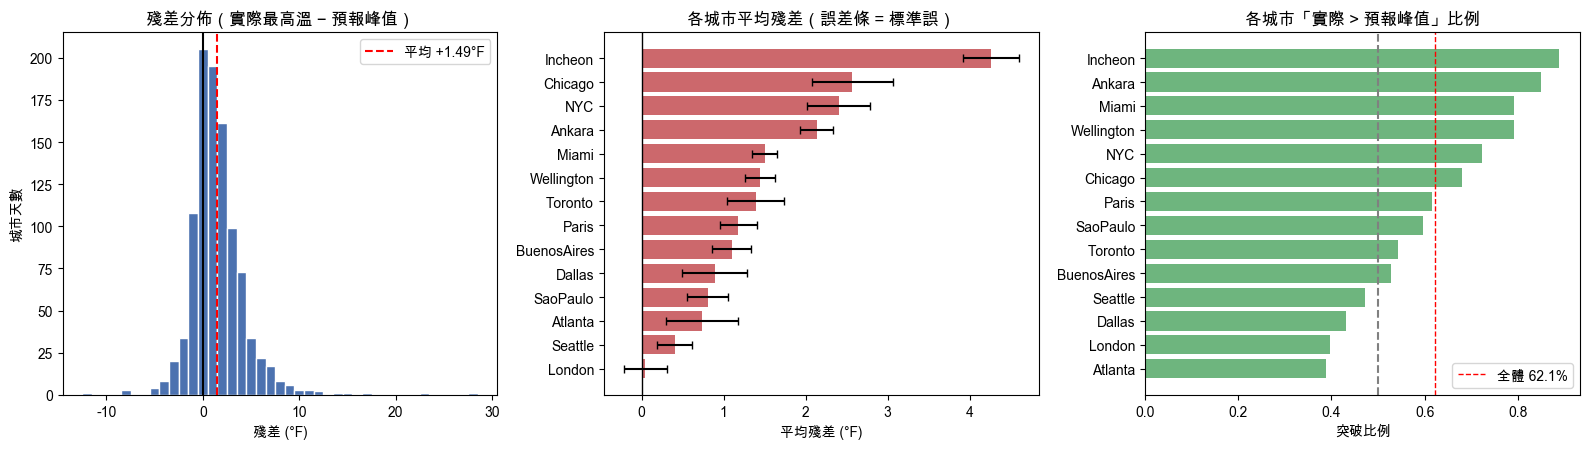

,mean,std,count,breakout_rate
city,,,,
London,0.04,2.24,73,0.40
Seattle,0.40,1.84,72,0.47
Atlanta,0.74,3.75,72,0.39
SaoPaulo,0.81,2.14,72,0.60
Dallas,0.89,3.33,72,0.43
BuenosAires,1.10,1.99,72,0.53
Paris,1.18,1.92,73,0.62
Toronto,1.39,2.98,72,0.54
Wellington,1.44,1.56,72,0.79


In [18]:
res = df["residual"]
n = len(df)
n_break, n_match, n_below = (res > 0).sum(), (res == 0).sum(), (res < 0).sum()
print(f"全體 {n} 城市天  |  突破(實際>預報) {n_break} ({n_break/n:.1%})  |  "
      f"持平 {n_match} ({n_match/n:.1%})  |  低於 {n_below} ({n_below/n:.1%})")
print(f"殘差  mean={res.mean():+.2f}°F   median={res.median():+.1f}°F   std={res.std():.2f}°F")
print(f"|殘差| ≤1°F：{(res.abs()<=1).mean():.1%}    ≤2°F：{(res.abs()<=2).mean():.1%}")

by_city = df.groupby("city")["residual"].agg(["mean", "std", "count"]).sort_values("mean")
by_city["se"] = by_city["std"] / np.sqrt(by_city["count"])
by_city["breakout_rate"] = df.groupby("city")["breakout"].mean()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
bins = np.arange(res.min() - 0.5, res.max() + 1.5, 1)
ax[0].hist(res, bins=bins, color="#4C72B0", edgecolor="white")
ax[0].axvline(0, color="black", lw=1.5)
ax[0].axvline(res.mean(), color="red", ls="--", lw=1.5, label=f"平均 {res.mean():+.2f}°F")
ax[0].set_title("殘差分佈（實際最高溫 − 預報峰值）", fontweight="bold")
ax[0].set_xlabel("殘差 (°F)"); ax[0].set_ylabel("城市天數"); ax[0].legend()

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in by_city["mean"]]
ax[1].barh(by_city.index, by_city["mean"], xerr=by_city["se"], color=colors, alpha=.85, capsize=3)
ax[1].axvline(0, color="black", lw=1)
ax[1].set_title("各城市平均殘差（誤差條 = 標準誤）", fontweight="bold")
ax[1].set_xlabel("平均殘差 (°F)")

bc = by_city.sort_values("breakout_rate")
ax[2].barh(bc.index, bc["breakout_rate"], color="#55A868", alpha=.85)
ax[2].axvline(0.5, color="gray", ls="--")
ax[2].axvline(df["breakout"].mean(), color="red", ls="--", lw=1, label=f"全體 {df['breakout'].mean():.1%}")
ax[2].set_title("各城市「實際 > 預報峰值」比例", fontweight="bold")
ax[2].set_xlabel("突破比例"); ax[2].legend()
plt.tight_layout(); plt.show()
by_city.drop(columns="se").round(2)

## 2️⃣ 核心假設：「平台型」走勢更容易突破嗎？

`plateau_w` = 預報曲線中，溫度落在峰值往下 `PLATEAU_TOL_F`（預設 1）°F 以內的小時數。

- `plateau_w ≤ 2` → 尖峰型（峰值很「尖」，附近沒幾小時跟著）
- `plateau_w ≥ 6` → 平台型（下午一大段都黏在峰值）

**假設**：平台型 → 實際最高溫更可能往上突破，而且殘差變異更大（風險更高）。
用「分組統計 + bootstrap CI」看趨勢，再用「Logistic 回歸（控制氣候帶 / 振幅 / 體感差 / 風速）」隔離 `plateau_w` 自己的效果。


               n  mean_resid  std_resid  breakout_rate  br_lo  br_hi  \
plateau_bin                                                            
≤2h\n(尖峰)     26       0.731      3.365          0.462  0.269  0.654   
3h           168       0.554      2.480          0.488  0.411  0.560   
4-5h         513       1.310      2.315          0.595  0.550  0.634   
6h+\n(平台)    304       2.372      3.458          0.753  0.704  0.796   

             p_exceed_+2F  
plateau_bin                
≤2h\n(尖峰)           0.346  
3h                  0.298  
4-5h                0.415  
6h+\n(平台)           0.530  


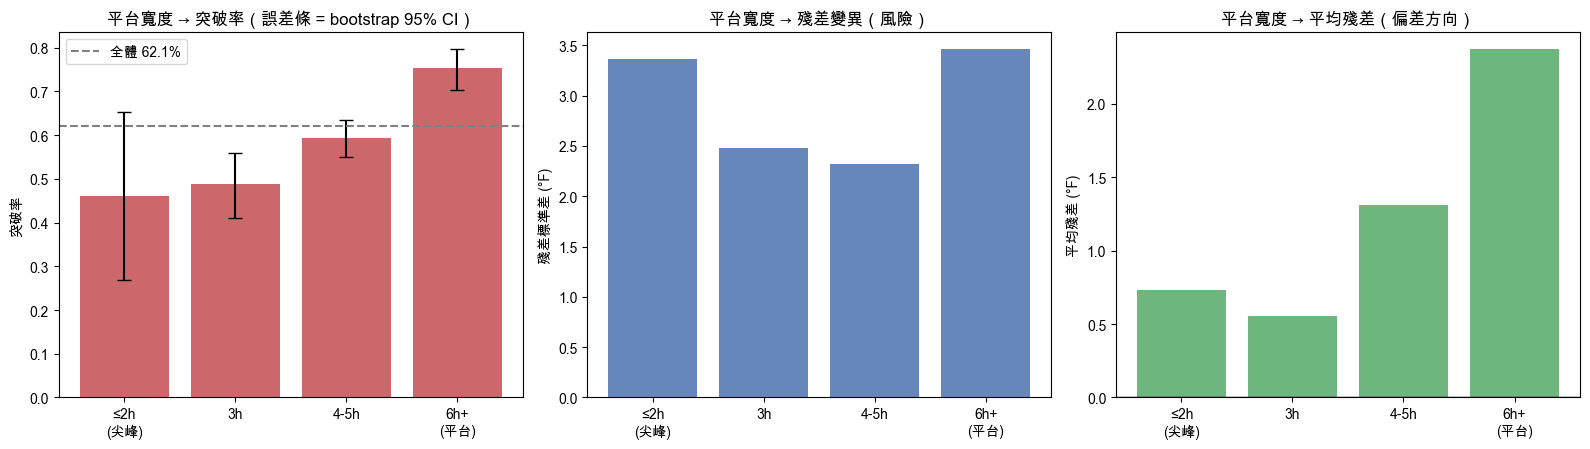


=== Logistic 回歸：P(突破) ===
                         Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
Intercept              -0.7025    0.4505 -1.5595  0.1189 -1.5854  0.1804
C(zone)[T.subtropical]  0.1456    0.2909  0.5005  0.6167 -0.4245  0.7157
C(zone)[T.temperate]    1.2340    0.2607  4.7326  0.0000  0.7230  1.7451
C(zone)[T.tropical]     0.5419    0.3634  1.4909  0.1360 -0.1705  1.2542
plateau_w               0.1387    0.0441  3.1410  0.0017  0.0521  0.2252
fc_range               -0.0276    0.0125 -2.2178  0.0266 -0.0521 -0.0032
feels_gap_peak          0.1416    0.0300  4.7143  0.0000  0.0827  0.2005
wind_day_mean           0.0320    0.0189  1.6871  0.0916 -0.0052  0.0691

plateau_w 每多 1 小時 → 突破勝算比 (odds ratio) ×1.149  (↑14.9%／小時，p=0.002)
殘差 OLS：plateau_w 係數 = +0.2449°F／小時 (p=0.000)


In [19]:
import statsmodels.api as sm
from statsmodels.formula.api import logit, ols

df["plateau_bin"] = pd.cut(df["plateau_w"], bins=[0, 2, 3, 5, 99],
                           labels=["≤2h\n(尖峰)", "3h", "4-5h", "6h+\n(平台)"])
def boot_ci(x, fn=np.mean, n=2000):
    x = np.asarray(x, float)
    bs = [fn(np.random.choice(x, len(x), replace=True)) for _ in range(n)]
    return np.percentile(bs, [2.5, 97.5])

rows = []
for b, gg in df.groupby("plateau_bin", observed=True):
    lo, hi = boot_ci(gg["breakout"].values)
    rows.append({"plateau_bin": b, "n": len(gg),
                 "mean_resid": gg["residual"].mean(), "std_resid": gg["residual"].std(),
                 "breakout_rate": gg["breakout"].mean(), "br_lo": lo, "br_hi": hi,
                 "p_exceed_+2F": (gg["residual"] >= 2).mean()})
tab = pd.DataFrame(rows).set_index("plateau_bin")
print(tab.round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
x = np.arange(len(tab))
ax[0].bar(x, tab["breakout_rate"],
          yerr=[tab["breakout_rate"] - tab["br_lo"], tab["br_hi"] - tab["breakout_rate"]],
          color="#C44E52", alpha=.85, capsize=5)
ax[0].axhline(df["breakout"].mean(), color="gray", ls="--", label=f"全體 {df['breakout'].mean():.1%}")
ax[0].set_xticks(x); ax[0].set_xticklabels(tab.index); ax[0].set_ylabel("突破率")
ax[0].set_title("平台寬度 → 突破率（誤差條 = bootstrap 95% CI）", fontweight="bold"); ax[0].legend()
ax[1].bar(x, tab["std_resid"], color="#4C72B0", alpha=.85)
ax[1].set_xticks(x); ax[1].set_xticklabels(tab.index); ax[1].set_ylabel("殘差標準差 (°F)")
ax[1].set_title("平台寬度 → 殘差變異（風險）", fontweight="bold")
ax[2].bar(x, tab["mean_resid"], color="#55A868", alpha=.85)
ax[2].axhline(0, color="black", lw=1)
ax[2].set_xticks(x); ax[2].set_xticklabels(tab.index); ax[2].set_ylabel("平均殘差 (°F)")
ax[2].set_title("平台寬度 → 平均殘差（偏差方向）", fontweight="bold")
plt.tight_layout(); plt.show()

md_ = df.dropna(subset=["plateau_w", "fc_range", "feels_gap_peak", "wind_day_mean", "zone"]).copy()
m_logit = logit("breakout ~ plateau_w + fc_range + feels_gap_peak + wind_day_mean + C(zone)",
                data=md_).fit(disp=0)
print("\n=== Logistic 回歸：P(突破) ===")
print(m_logit.summary2().tables[1].round(4))
or_ = float(np.exp(m_logit.params["plateau_w"]))
p_pw = float(m_logit.pvalues["plateau_w"])
print(f"\nplateau_w 每多 1 小時 → 突破勝算比 (odds ratio) ×{or_:.3f}  "
      f"({'↑' if or_>1 else '↓'}{abs(or_-1)*100:.1f}%／小時，p={p_pw:.3f})")

m_ols = ols("residual ~ plateau_w + fc_range + feels_gap_peak + C(zone)", data=md_).fit()
print(f"殘差 OLS：plateau_w 係數 = {m_ols.params['plateau_w']:+.4f}°F／小時 (p={m_ols.pvalues['plateau_w']:.3f})")

## 3️⃣ 風險帶：分位數回歸預測當天最高溫的 P10 / P50 / P90

用 **梯度提升分位數回歸**（Gradient Boosting, quantile loss）預測 `actual_high` 的 10% / 50% / 90% 分位數。
所有預測值都用 **「以日期分組」的交叉驗證** 做出（out-of-fold），避免過擬合造成的虛假準確。

- **風險分數 `risk_score` = P90 − P10**（80% 區間寬度）→ 越寬代表那天越難預測
- **校準檢查**：實際最高溫落在 [P10, P90] 內的比例應該 ≈ 80%


P50 預測 MAE = 1.929°F   |   基準（直接用預報峰值）MAE = 2.130°F   → 改善 +0.201°F
80% 區間覆蓋率 = 73.3%（目標 80%）
風險分數 risk_score：mean=5.94°F  min=1.0  P90=9.1  max=26.5


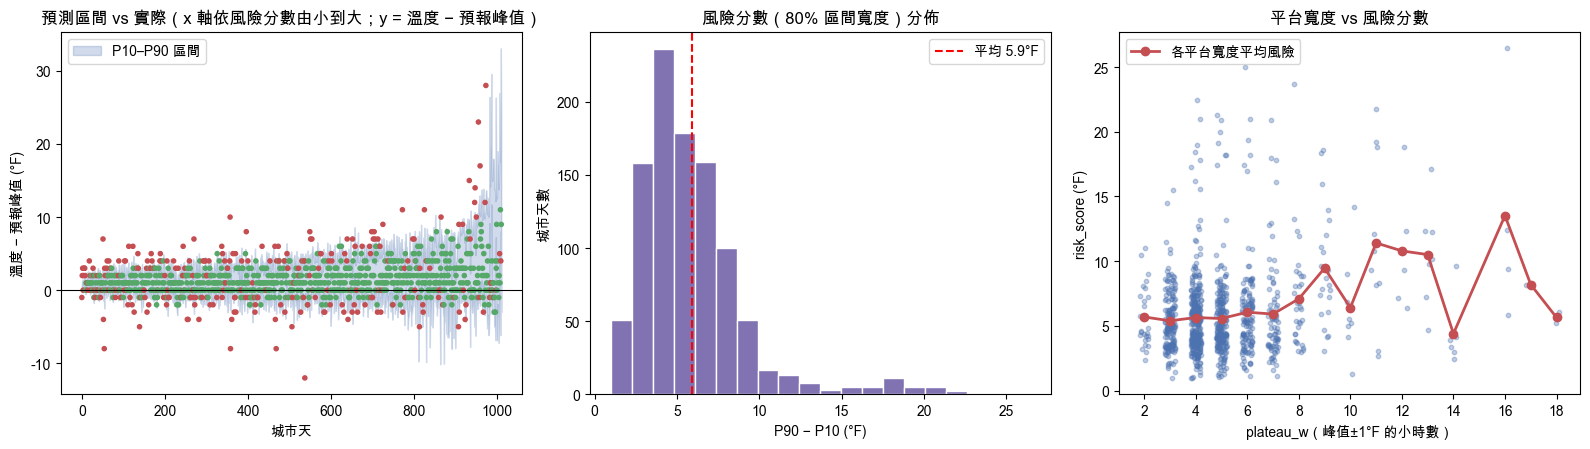


🔴 風險最高 8 天：
   city target_date  fc_peak  actual_high  residual  pred_q10  pred_q90  risk_score  plateau_w  fc_range  feels_gap_peak
Chicago  2026-03-11     37.0         46.0       9.0     33.99     60.44       26.45       16.0       3.0            -9.0
Toronto  2026-03-17     23.0         27.0       4.0     31.09     56.08       24.99        6.0       7.0           -15.0
    NYC  2026-03-12     45.0         56.0      11.0     38.87     62.55       23.67        8.0       9.0            -8.0
Toronto  2026-03-27     31.0         32.0       1.0     30.30     52.78       22.48        4.0      11.0            -8.0
Chicago  2026-03-16     26.0         31.0       5.0     31.20     52.97       21.77       11.0       7.0           -15.0
Toronto  2026-03-03     35.0         37.0       2.0     30.26     51.55       21.30        5.0      18.0            -7.0
Toronto  2026-03-13     37.0         36.0      -1.0     29.79     50.81       21.02        6.0      13.0            -8.0
Toronto  2026-04-07

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

FEATURES_NUM = ["fc_peak", "fc_peak_hour", "fc_min", "fc_range", "n_at_peak", "plateau_w", "plateau_w2",
                "afternoon_mean", "morning_min", "rise_4h", "fall_4h", "curv_peak", "feels_gap_peak",
                "wind_peak", "wind_day_mean", "late_peak", "prev_fc_error", "prev_humidity",
                "prev_dewpoint", "prev_pressure", "pressure_delta", "fc_minus_prev_actual",
                "doy_sin", "doy_cos", "lead_hours", "lat"]
FEATURES_CAT = ["zone"]
ALL_FEATS = FEATURES_NUM + FEATURES_CAT

dfm = df.copy()
for c in FEATURES_NUM:
    dfm[c] = dfm[c].fillna(dfm[c].median())
X = dfm[ALL_FEATS]
y = dfm["actual_high"].values
groups = dfm["target_date"].astype(str).values

def _pre():
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)],
                             remainder="passthrough")
def make_gbr(alpha):
    return Pipeline([("pre", _pre()),
                     ("gbr", GradientBoostingRegressor(loss="quantile", alpha=alpha, n_estimators=300,
                              max_depth=2, learning_rate=0.04, subsample=0.8, min_samples_leaf=20,
                              random_state=RANDOM_SEED))])

gkf = GroupKFold(n_splits=N_CV_SPLITS)
oof = {q: np.zeros(len(dfm)) for q in QUANTILES}
for tr, te in gkf.split(X, y, groups):
    for q in QUANTILES:
        oof[q][te] = make_gbr(q).fit(X.iloc[tr], y[tr]).predict(X.iloc[te])
q10, q50, q90 = oof[0.10], oof[0.50], oof[0.90]
q10 = np.minimum(q10, q50); q90 = np.maximum(q90, q50)          # 修正偶發的分位數交叉
dfm["pred_q10"], dfm["pred_q50"], dfm["pred_q90"] = q10, q50, q90
dfm["risk_score"] = q90 - q10
dfm["covered80"]  = ((dfm["actual_high"] >= q10) & (dfm["actual_high"] <= q90)).astype(int)

mae_model = float(np.abs(dfm["actual_high"] - q50).mean())
mae_base  = float(np.abs(dfm["actual_high"] - dfm["fc_peak"]).mean())
print(f"P50 預測 MAE = {mae_model:.3f}°F   |   基準（直接用預報峰值）MAE = {mae_base:.3f}°F"
      f"   → {'改善' if mae_model < mae_base else '未改善'} {mae_base - mae_model:+.3f}°F")
print(f"80% 區間覆蓋率 = {dfm['covered80'].mean():.1%}（目標 80%）")
print(f"風險分數 risk_score：mean={dfm['risk_score'].mean():.2f}°F  "
      f"min={dfm['risk_score'].min():.1f}  P90={dfm['risk_score'].quantile(0.9):.1f}  max={dfm['risk_score'].max():.1f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ss = dfm.sort_values("risk_score").reset_index(drop=True)
xr = np.arange(len(ss))
ax[0].fill_between(xr, ss["pred_q10"] - ss["fc_peak"], ss["pred_q90"] - ss["fc_peak"],
                   alpha=.25, color="#4C72B0", label="P10–P90 區間")
ax[0].scatter(xr, ss["actual_high"] - ss["fc_peak"], s=9,
              c=np.where(ss["covered80"] == 1, "#55A868", "#C44E52"))
ax[0].axhline(0, color="black", lw=.8)
ax[0].set_title("預測區間 vs 實際（x 軸依風險分數由小到大；y = 溫度 − 預報峰值）", fontweight="bold")
ax[0].set_xlabel("城市天"); ax[0].set_ylabel("溫度 − 預報峰值 (°F)"); ax[0].legend(loc="upper left")
ax[1].hist(dfm["risk_score"], bins=20, color="#8172B2", edgecolor="white")
ax[1].axvline(dfm["risk_score"].mean(), color="red", ls="--", label=f"平均 {dfm['risk_score'].mean():.1f}°F")
ax[1].set_title("風險分數（80% 區間寬度）分佈", fontweight="bold")
ax[1].set_xlabel("P90 − P10 (°F)"); ax[1].set_ylabel("城市天數"); ax[1].legend()
jw = dfm["plateau_w"] + np.random.uniform(-.2, .2, len(dfm))
ax[2].scatter(jw, dfm["risk_score"], s=10, alpha=.35, color="#4C72B0")
mb = dfm.groupby("plateau_w")["risk_score"].mean()
ax[2].plot(mb.index, mb.values, "o-", color="#C44E52", lw=2, label="各平台寬度平均風險")
ax[2].set_title("平台寬度 vs 風險分數", fontweight="bold")
ax[2].set_xlabel("plateau_w（峰值±1°F 的小時數）"); ax[2].set_ylabel("risk_score (°F)"); ax[2].legend()
plt.tight_layout(); plt.show()

cols = ["city", "target_date", "fc_peak", "actual_high", "residual",
        "pred_q10", "pred_q90", "risk_score", "plateau_w", "fc_range", "feels_gap_peak"]
print("\n🔴 風險最高 8 天：")
print(dfm.nlargest(8, "risk_score")[cols].round(2).to_string(index=False))
print("\n🟢 風險最低 8 天：")
print(dfm.nsmallest(8, "risk_score")[cols].round(2).to_string(index=False))

## 4️⃣ 特徵重要性：什麼決定「實際高溫」、什麼決定「風險」？

用隨機森林 + 排列重要性（permutation importance，在「以日期分組」的 hold-out 折上計算）：

- **模型 A** 預測 `residual`（實際 − 預報峰值）→ 哪些特徵能修正預報偏差
- **模型 B** 預測 `risk_score` → 哪些特徵讓一天「難預測」

接著做 **誠實驗證**：模型 vs「直接相信預報峰值」的點預測誤差比較。


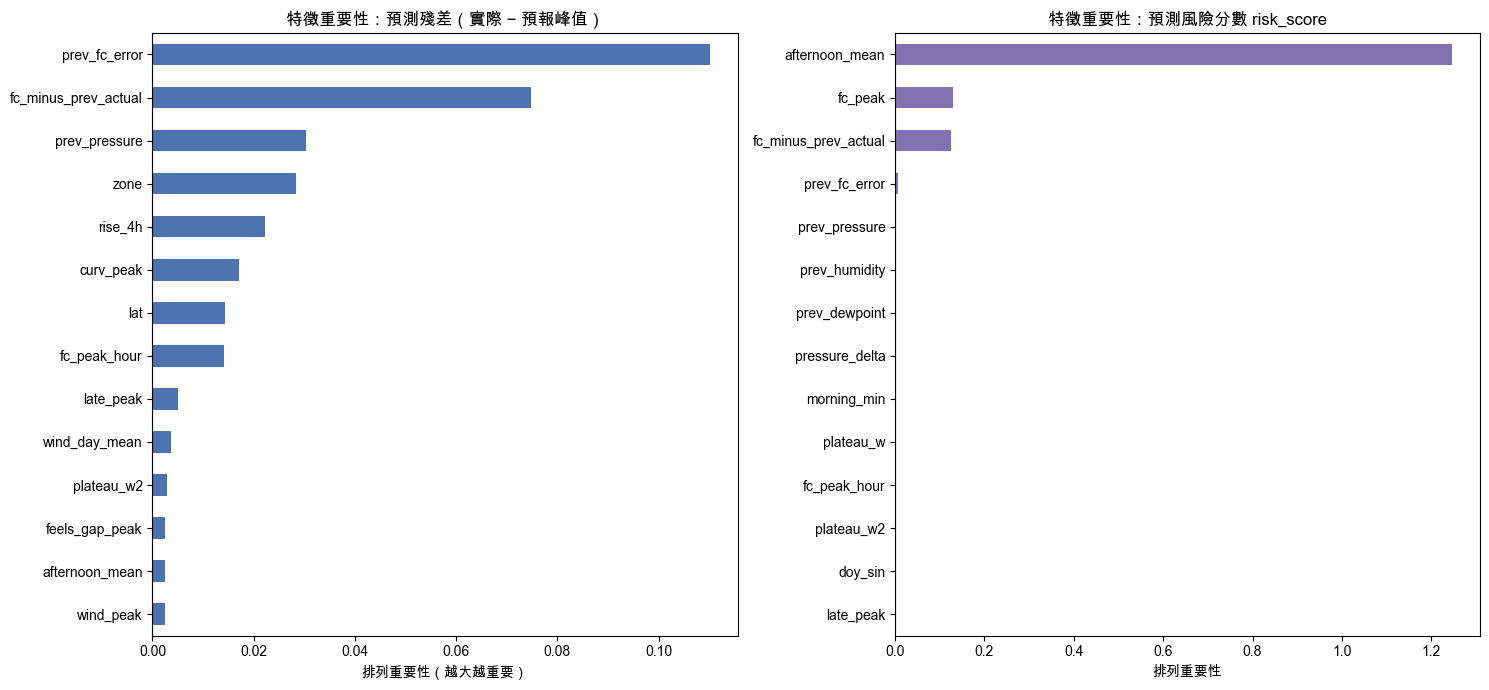

=== 點預測：誰最準（out-of-fold） ===
                MAE(°F)  RMSE(°F) 誤差≤1°F
模型                                      
基準：直接用預報峰值        2.130     3.197  50.2%
分位數GBR 中位數 P50    1.929     2.894  38.8%
隨機森林 殘差修正         1.734     2.479  40.2%

突破(實際>預報) 分類 AUC = 0.685  （0.5 = 沒資訊；> 0.6 才算有點用）
80% 區間覆蓋率 = 73.3%  （理想 80%；過高=區間太寬，過低=低估風險）


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def rf_pipe():
    return Pipeline([("pre", _pre()),
                     ("rf", RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=10,
                              random_state=RANDOM_SEED, n_jobs=-1))])

def grouped_perm_importance(target, n_repeats=8):
    imp = np.zeros((N_CV_SPLITS, len(ALL_FEATS)))
    for i, (tr, te) in enumerate(gkf.split(X, target, groups)):
        m = rf_pipe().fit(X.iloc[tr], target[tr])
        r = permutation_importance(m, X.iloc[te], target[te], n_repeats=n_repeats,
                                   random_state=RANDOM_SEED)
        imp[i] = r.importances_mean
    return pd.Series(imp.mean(0), index=ALL_FEATS).sort_values()

imp_resid = grouped_perm_importance(dfm["residual"].values)
imp_risk  = grouped_perm_importance(dfm["risk_score"].values)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
imp_resid.tail(14).plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set_title("特徵重要性：預測殘差（實際 − 預報峰值）", fontweight="bold")
ax[0].set_xlabel("排列重要性（越大越重要）"); ax[0].axvline(0, color="gray", lw=.8)
imp_risk.tail(14).plot.barh(ax=ax[1], color="#8172B2")
ax[1].set_title("特徵重要性：預測風險分數 risk_score", fontweight="bold")
ax[1].set_xlabel("排列重要性"); ax[1].axvline(0, color="gray", lw=.8)
plt.tight_layout(); plt.show()

# ── 誠實驗證：模型 vs「直接相信預報」──────────────────────────────────────────
oof_resid = np.zeros(len(dfm))
for tr, te in gkf.split(X, dfm["residual"].values, groups):
    oof_resid[te] = rf_pipe().fit(X.iloc[tr], dfm["residual"].values[tr]).predict(X.iloc[te])
pred_high_rf = dfm["fc_peak"].values + oof_resid

oof_break = np.zeros(len(dfm))
def lr_pipe():
    return Pipeline([("pre", _pre()), ("lr", LogisticRegression(max_iter=3000))])
for tr, te in gkf.split(X, dfm["breakout"].values, groups):
    oof_break[te] = lr_pipe().fit(X.iloc[tr], dfm["breakout"].values[tr]).predict_proba(X.iloc[te])[:, 1]

def m_row(name, pred):
    a = dfm["actual_high"].values
    return {"模型": name, "MAE(°F)": round(float(np.abs(a - pred).mean()), 3),
            "RMSE(°F)": round(float(np.sqrt(((a - pred) ** 2).mean())), 3),
            "誤差≤1°F": f"{float((np.abs(a - pred) <= 1).mean()):.1%}"}
cmp = pd.DataFrame([
    m_row("基準：直接用預報峰值", dfm["fc_peak"].values),
    m_row("分位數GBR 中位數 P50", dfm["pred_q50"].values),
    m_row("隨機森林 殘差修正", pred_high_rf),
]).set_index("模型")
print("=== 點預測：誰最準（out-of-fold） ===")
print(cmp)
auc_break = float(roc_auc_score(dfm["breakout"], oof_break))
print(f"\n突破(實際>預報) 分類 AUC = {auc_break:.3f}  （0.5 = 沒資訊；> 0.6 才算有點用）")
print(f"80% 區間覆蓋率 = {dfm['covered80'].mean():.1%}  （理想 80%；過高=區間太寬，過低=低估風險）")

## 5️⃣ Polymarket 區間命中：模型 vs 市場隱含機率

把每天的預測分佈（假設 `actual_high ~ Normal(P50, σ)`，σ 由 80% 區間反推 = (P90−P10)/2.563）
投影到 Polymarket 的溫度區間上 → 得到「模型版」各區間機率（°C 城市先把預測換成 °C）。

- 模型挑的最可能區間 vs 實際結算區間 → **命中率**（對比基準：含預報峰值的那個區間）
- 模型機率 vs 市場隱含機率（同 lead time 的賠率快照）→ 找 **錯價 edge**


區間命中率（842 城市天）：模型(最高機率區間) 41.6%   vs   基準(含預報峰值的區間) 42.3%
對「實際結算區間」：模型平均給 33.7% 機率；市場平均給 40.4%   → 市場較貼近真相（n=841）


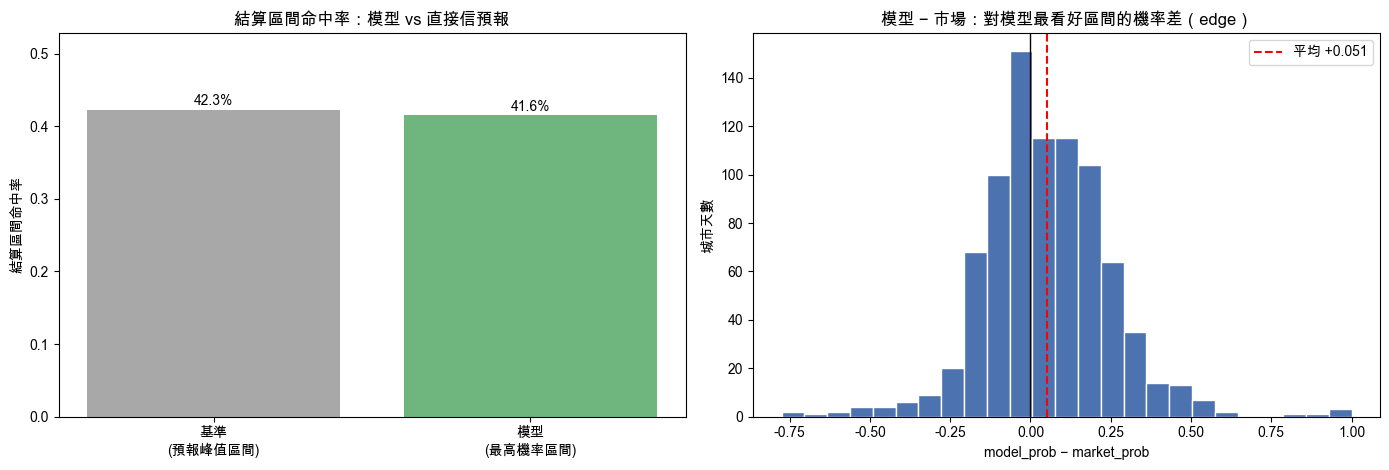


若採「模型 edge > 門檻 → 就買那個區間」：
  edge>5%：396 筆  →  模型挑的區間實際命中 29.5%；市場對這些區間平均只給 26.4%（隱含勝率）
  edge>10%：324 筆  →  模型挑的區間實際命中 27.8%；市場對這些區間平均只給 23.9%（隱含勝率）
  edge>15%：238 筆  →  模型挑的區間實際命中 24.8%；市場對這些區間平均只給 21.7%（隱含勝率）


In [22]:
from scipy.stats import norm

RANGE_RE = re.compile(r"(-?\d+)\s*-\s*(-?\d+)")
ABOVE_RE = re.compile(r"or\s+(higher|above)", re.I)
BELOW_RE = re.compile(r"or\s+below", re.I)
NUM_RE   = re.compile(r"(-?\d+)")
f_to_c   = lambda f: (f - 32) * 5.0 / 9.0

def parse_buckets(labels):
    """labels: 依 rank 排序的 list。回傳 [(lo, hi), ...] 半開區間 [lo, hi)，單位 = 市場單位；無法乾淨解析就回傳 None。"""
    n = len(labels)
    b = [None] * n
    for i, lab in enumerate(labels):
        if ABOVE_RE.search(lab) or BELOW_RE.search(lab):
            continue
        m = RANGE_RE.search(lab)
        if m:
            b[i] = (int(m.group(1)), int(m.group(2)) + 1); continue
        m = NUM_RE.search(lab)
        if m:
            t = int(m.group(1)); b[i] = (t - 0.5, t + 0.5)
    # 開放端：第一個 = (-inf, 下一桶下界)，最後一個 = (上一桶上界, +inf)
    if n > 1 and b[0] is None and b[1] is not None:
        b[0] = (-np.inf, b[1][0])
    if n > 1 and b[-1] is None and b[-2] is not None:
        b[-1] = (b[-2][1], np.inf)
    return b if all(x is not None for x in b) else None

def find_idx(bounds, v):
    for i, (lo, hi) in enumerate(bounds):
        if lo <= v < hi:
            return i
    return np.nan

conn = get_conn()
opts = pd.read_sql("SELECT location_key, market_date, option_label, option_rank FROM market_options", conn)
msnap = pd.read_sql(f"""
  SELECT DISTINCT ON (location_key, market_date, option_label)
         location_key, market_date, option_label, yes_prob
  FROM market_snapshots
  WHERE market_date >= %(since)s AND yes_prob IS NOT NULL
    AND hours_before_close BETWEEN %(lo)s AND %(hi)s
  ORDER BY location_key, market_date, option_label, abs(hours_before_close - %(tgt)s)
""", conn, params={"since": SINCE_DATE, "lo": LEAD_HOURS_WINDOW[0],
                   "hi": LEAD_HOURS_WINDOW[1], "tgt": LEAD_HOURS_TARGET})
conn.close()
opts["market_date"] = pd.to_datetime(opts["market_date"]).dt.date
msnap["market_date"] = pd.to_datetime(msnap["market_date"]).dt.date
cel = dict(zip(df["location_key"], df["celsius"]))

rows = []
for _, r in dfm.iterrows():
    lk, d = r["location_key"], r["target_date"]
    is_c = bool(cel.get(lk, False))
    labs = opts[(opts.location_key == lk) & (opts.market_date == d)].sort_values("option_rank")
    if len(labs) < 3:
        continue
    bounds = parse_buckets(list(labs["option_label"]))
    if bounds is None:
        continue
    conv  = (lambda v: f_to_c(v)) if is_c else (lambda v: v)
    mu    = conv(r["pred_q50"])
    sd    = (r["pred_q90"] - r["pred_q10"]) / (2 * 1.2816)
    sd    = max(sd * (5.0 / 9.0) if is_c else sd, 0.4)
    a_v   = conv(r["actual_high"]); pk_v = conv(r["fc_peak"])
    p = np.array([norm.cdf(hi, mu, sd) - norm.cdf(lo, mu, sd) for lo, hi in bounds])
    p = p / p.sum()
    a_i  = find_idx(bounds, a_v)
    pk_i = find_idx(bounds, pk_v)
    md_i = int(np.argmax(p))
    msl  = msnap[(msnap.location_key == lk) & (msnap.market_date == d)]
    mkt  = labs["option_label"].map(dict(zip(msl.option_label, msl.yes_prob)))
    mkt  = pd.to_numeric(mkt, errors="coerce").values
    rows.append({
        "city": r["city"], "date": d, "a_i": a_i, "pk_i": pk_i, "md_i": md_i,
        "model_hit": (int(a_i == md_i) if not np.isnan(a_i) else np.nan),
        "peak_hit":  (int(a_i == pk_i) if not np.isnan(a_i) else np.nan),
        "model_p_actual": (p[int(a_i)] if not np.isnan(a_i) else np.nan),
        "mkt_p_actual":   (mkt[int(a_i)] if (not np.isnan(a_i) and not np.isnan(mkt[int(a_i)])) else np.nan),
        "model_p_md": p[md_i],
        "mkt_p_md":   (mkt[md_i] if not np.isnan(mkt[md_i]) else np.nan),
    })
bk = pd.DataFrame(rows)
valid = bk.dropna(subset=["model_hit", "peak_hit"])
print(f"區間命中率（{len(valid)} 城市天）：模型(最高機率區間) {valid['model_hit'].mean():.1%}"
      f"   vs   基準(含預報峰值的區間) {valid['peak_hit'].mean():.1%}")
ea = bk.dropna(subset=["model_p_actual", "mkt_p_actual"])
print(f"對「實際結算區間」：模型平均給 {ea['model_p_actual'].mean():.1%} 機率；市場平均給 {ea['mkt_p_actual'].mean():.1%}"
      f"   → {'模型較貼近真相' if ea['model_p_actual'].mean() > ea['mkt_p_actual'].mean() else '市場較貼近真相'}（n={len(ea)}）")

e2 = bk.dropna(subset=["mkt_p_md", "a_i"]).copy()
e2["edge"] = e2["model_p_md"] - e2["mkt_p_md"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
vals = [valid["peak_hit"].mean(), valid["model_hit"].mean()]
ax[0].bar(["基準\n(預報峰值區間)", "模型\n(最高機率區間)"], vals, color=["#999999", "#55A868"], alpha=.85)
for i, v in enumerate(vals):
    ax[0].text(i, v + .006, f"{v:.1%}", ha="center", fontweight="bold")
ax[0].set_ylabel("結算區間命中率"); ax[0].set_ylim(0, max(vals) * 1.25)
ax[0].set_title("結算區間命中率：模型 vs 直接信預報", fontweight="bold")
ax[1].hist(e2["edge"], bins=25, color="#4C72B0", edgecolor="white")
ax[1].axvline(0, color="black", lw=1)
ax[1].axvline(e2["edge"].mean(), color="red", ls="--", label=f"平均 {e2['edge'].mean():+.3f}")
ax[1].set_title("模型 − 市場：對模型最看好區間的機率差（edge）", fontweight="bold")
ax[1].set_xlabel("model_prob − market_prob"); ax[1].set_ylabel("城市天數"); ax[1].legend()
plt.tight_layout(); plt.show()

print("\n若採「模型 edge > 門檻 → 就買那個區間」：")
for thr in [0.05, 0.10, 0.15]:
    pick = e2[e2["edge"] > thr]
    if len(pick) == 0:
        print(f"  edge>{thr:.0%}：無樣本"); continue
    hit = float((pick["md_i"] == pick["a_i"]).mean())
    print(f"  edge>{thr:.0%}：{len(pick):3d} 筆  →  模型挑的區間實際命中 {hit:.1%}；"
          f"市場對這些區間平均只給 {pick['mkt_p_md'].mean():.1%}（隱含勝率）")

## 6️⃣ 總結

In [23]:
big_risk = dfm["risk_score"].quantile(0.9)
mean_resid = dfm["residual"].mean()
bias_txt = ("WU 系統性低估峰值（實際往往比預報高，可考慮把預報峰值往上修一點）" if mean_resid > 0.15
            else "WU 系統性高估峰值（實際往往比預報低）" if mean_resid < -0.15
            else "沒有明顯系統性偏差")
pw_txt = ("假設成立：控制其他變數後，平台型確實更容易往上突破" if (or_ > 1.05 and p_pw < 0.10)
          else "假設方向對但不顯著（樣本還太少）" if or_ > 1.05
          else "假設不成立／很弱：平台寬度對『突破方向』影響有限")
model_txt = ("模型對『修正預報、量化風險』有一定價值" if (mae_model < mae_base - 0.02 or auc_break > 0.6)
             else "模型沒有明顯打敗『直接相信預報』——74 天資料還太少，先別過度依賴")

print("=" * 72)
print(" 氣溫走勢與風險建模 — 重點結論")
print("=" * 72)
print(f"""
資料：{len(dfm)} 城市天（{dfm['city'].nunique()} 城市 × {dfm['target_date'].nunique()} 日期），預報快照取結算前約 {LEAD_HOURS_TARGET}h。

【1. 預報偏差】
  實際最高溫 − 預報峰值：平均 {mean_resid:+.2f}°F，標準差 {dfm['residual'].std():.2f}°F；
  突破(實際>預報) {dfm['breakout'].mean():.1%}，|誤差|≤1°F 佔 {(dfm['residual'].abs()<=1).mean():.1%}。
  → {bias_txt}

【2. 平台期假設】
  尖峰型(plateau_w≤2) 突破率 {df.loc[df.plateau_w<=2,'breakout'].mean():.1%}；平台型(plateau_w≥6) 突破率 {df.loc[df.plateau_w>=6,'breakout'].mean():.1%}。
  Logistic：plateau_w 每多 1 小時 → 突破勝算比 ×{or_:.2f}（p={p_pw:.3f}，已控制氣候帶/振幅/體感差/風速）。
  → {pw_txt}

【3. 風險帶 & 風險來源】
  80% 區間平均寬度 {dfm['risk_score'].mean():.1f}°F（P90 達 {big_risk:.1f}°F），覆蓋率 {dfm['covered80'].mean():.1%}。
  推升「當天難預測」的特徵 top3（排列重要性）：{', '.join(list(imp_risk.tail(3).index)[::-1])}
  能修正「預報偏差」的特徵 top3：{', '.join(list(imp_resid.tail(3).index)[::-1])}

【4. 模型有沒有用】
  點預測 MAE：模型 P50 {mae_model:.2f}°F vs 直接信預報 {mae_base:.2f}°F；突破分類 AUC {auc_break:.2f}。
  → {model_txt}

【5. Polymarket】
  結算區間命中率：模型 {valid['model_hit'].mean():.1%} vs 基準(預報峰值區間) {valid['peak_hit'].mean():.1%}。
  模型對「實際結算區間」給的機率 {ea['model_p_actual'].mean():.1%} vs 市場 {ea['mkt_p_actual'].mean():.1%}。

⚠️ 注意事項
  - 只有 {dfm['target_date'].nunique()} 個不同日期、且城市間高度相關，有效樣本遠小於 {len(dfm)} 列。
    所有「模型贏基準」的差距都要保守看待，建議資料累積到 3–6 個月後重跑驗證。
  - 實務建議：風險分數 ≥ {big_risk:.0f}°F 的日子（約最高風險的 10%）降低下注金額或直接跳過；
    優先下注在 risk_score 小、且模型 edge 為正的城市天。
""")

 氣溫走勢與風險建模 — 重點結論

資料：1011 城市天（14 城市 × 73 日期），預報快照取結算前約 20h。

【1. 預報偏差】
  實際最高溫 − 預報峰值：平均 +1.49°F，標準差 2.83°F；
  突破(實際>預報) 62.1%，|誤差|≤1°F 佔 50.2%。
  → WU 系統性低估峰值（實際往往比預報高，可考慮把預報峰值往上修一點）

【2. 平台期假設】
  尖峰型(plateau_w≤2) 突破率 46.2%；平台型(plateau_w≥6) 突破率 75.3%。
  Logistic：plateau_w 每多 1 小時 → 突破勝算比 ×1.15（p=0.002，已控制氣候帶/振幅/體感差/風速）。
  → 假設成立：控制其他變數後，平台型確實更容易往上突破

【3. 風險帶 & 風險來源】
  80% 區間平均寬度 5.9°F（P90 達 9.1°F），覆蓋率 73.3%。
  推升「當天難預測」的特徵 top3（排列重要性）：afternoon_mean, fc_peak, fc_minus_prev_actual
  能修正「預報偏差」的特徵 top3：prev_fc_error, fc_minus_prev_actual, prev_pressure

【4. 模型有沒有用】
  點預測 MAE：模型 P50 1.93°F vs 直接信預報 2.13°F；突破分類 AUC 0.68。
  → 模型對『修正預報、量化風險』有一定價值

【5. Polymarket】
  結算區間命中率：模型 41.6% vs 基準(預報峰值區間) 42.3%。
  模型對「實際結算區間」給的機率 33.7% vs 市場 40.4%。

⚠️ 注意事項
  - 只有 73 個不同日期、且城市間高度相關，有效樣本遠小於 1011 列。
    所有「模型贏基準」的差距都要保守看待，建議資料累積到 3–6 個月後重跑驗證。
  - 實務建議：風險分數 ≥ 9°F 的日子（約最高風險的 10%）降低下注金額或直接跳過；
    優先下注在 risk_score 小、且模型 edge 為正的城市天。

